# Análisis Exploratorio de Datos (EDA)
En este notebook realizaremos un análisis exploratorio enfocado en la variable objetivo `es_retraso`. Generaremos visualizaciones para entender la distribución y detectar patrones iniciales.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Ajustar estilo
sns.set_theme(style="whitegrid")

In [2]:
# Cargar la tabla master generada por Kedro
filepath = "../../data/03_primary/master_table.parquet"
df = pd.read_parquet(filepath, engine="fastparquet")
df.head()

,id_envio,fecha_envio,id_ruta,id_vehiculo,peso_kg,volumen_m3,estado,fecha_entrega,origen,destino,...,tipo_carga_peligrosa,tipo_carga_perecible,tipo_carga_refrigerada,tipo_via_camino rural,tipo_via_desconocido,tipo_via_ruta nacional,tipo_via_urbana,estado_vehiculo_en mantención,estado_vehiculo_fuera de servicio,estado_vehiculo_operativo
0,1,2023-01-01,desconocido,46,1.085132,28.48,entregado,2023-01-05,castro,angol,...,True,False,False,True,False,False,False,True,False,False
1,1,2023-01-01,desconocido,46,1.085132,28.48,entregado,2023-01-05,concepción,las condes,...,True,False,False,False,False,True,False,True,False,False
2,1,2023-01-01,desconocido,46,1.085132,28.48,entregado,2023-01-05,viña del mar,linares,...,True,False,False,False,False,False,False,True,False,False
3,2,NaT,3,27,-1.698870,24.93,entregado,2023-01-05,rancagua,rengo,...,True,False,False,False,False,False,True,False,False,True
4,3,2023-01-02,73,18,-1.144277,50.55,entregado,NaT,maipú,desconocido,...,False,False,True,False,False,True,False,True,False,False


## Distribución de la Variable Objetivo (`es_retraso`)

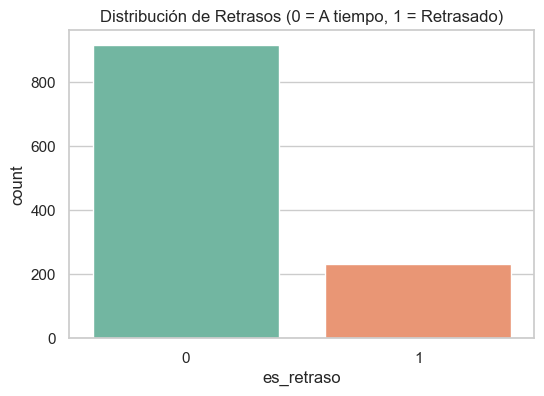

Porcentaje de retrasos:
es_retraso
0    79.94769
1    20.05231
Name: proportion, dtype: float64


In [3]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="es_retraso", palette="Set2")
plt.title("Distribución de Retrasos (0 = A tiempo, 1 = Retrasado)")
plt.show()

print("Porcentaje de retrasos:")
print(df["es_retraso"].value_counts(normalize=True) * 100)

## Correlaciones de Variables Numéricas

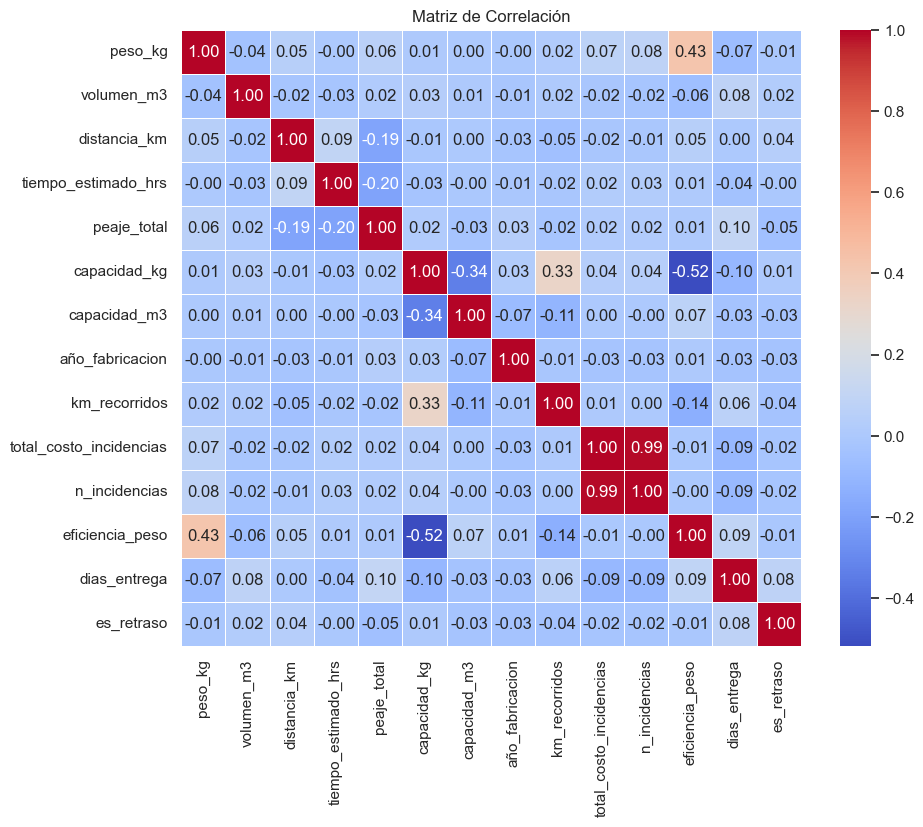

In [4]:
num_cols = df.select_dtypes(include=["number"]).columns
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación")
plt.show()